# Multi-Task Learning: Learning Multiple Tasks Together

**Multi-task learning (MTL)** is a training paradigm where a single model learns to solve multiple related tasks simultaneously. Instead of training separate models for each task, MTL leverages shared representations to improve generalization and efficiency.

## What We'll Learn

1. **Why multi-task learning?** - The benefits of learning multiple tasks together
2. **MTL fundamentals** - Hard vs soft parameter sharing, task relationships
3. **Architecture patterns** - Shared encoders, task-specific heads, advanced architectures
4. **Loss balancing** - The critical challenge of balancing multiple objectives
5. **Practical implementations** - Vision and NLP multi-task models
6. **Evaluation strategies** - Measuring performance across tasks

## Why This Matters

Multi-task learning is a powerful approach that:
- **Improves generalization** through shared representations
- **Reduces overfitting** via implicit regularization
- **Enables transfer learning** between related tasks
- **Reduces computational costs** by sharing parameters
- **Works with limited data** by leveraging related tasks

Real-world applications include autonomous driving (object detection + segmentation + depth estimation), medical diagnosis (multiple disease predictions), and natural language understanding (sentiment + NER + parsing).

## 1. Setup

### Import required libraries

In [1]:
# Standard library
from typing import Dict, List, Tuple, Optional
import math

# Third-party libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, f1_score

# Local library
from aiml_notebooks import (
    get_device, 
    set_seed, 
    count_parameters,
    create_dataset,
    create_dataloaders,
    TrainingHistory,
    CIFAR10_MEAN,
    CIFAR10_STD,
)

# Enable autoreload for development
%load_ext autoreload
%autoreload 2

### Set random seed for reproducibility

In [2]:
set_seed(42)

### Configure device (GPU if available)

In [3]:
device = get_device()
print(f"Using device: {device}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


## 2. Introduction to Multi-Task Learning

### Why Train on Multiple Tasks?

Consider a simple example: We want to classify handwritten digits (0-9) and also determine if they're even or odd.

**Single-task approach:**
- Train model A: digits → class (10-way classification)
- Train model B: digits → even/odd (2-way classification)
- Result: 2 separate models, 2x training time

**Multi-task approach:**
- Train one model: digits → (class, even/odd)
- Result: 1 shared model, both tasks learned together

The key insight: **Both tasks benefit from shared features** (edges, curves, shapes). The multi-task model learns these features once and uses them for both tasks.

### Create a toy multi-task dataset to demonstrate the concept

In [4]:
class ToyMultiTaskDataset(Dataset):
    """Simple dataset with 2 tasks: sum and product of two numbers."""
    
    def __init__(self, n_samples=1000, noise=0.1):
        self.n_samples = n_samples
        # Generate random input pairs
        self.X = torch.randn(n_samples, 2)
        # Task 1: sum of inputs
        self.y1 = (self.X[:, 0] + self.X[:, 1]).unsqueeze(1)
        # Task 2: product of inputs
        self.y2 = (self.X[:, 0] * self.X[:, 1]).unsqueeze(1)
        # Add noise
        self.y1 += torch.randn_like(self.y1) * noise
        self.y2 += torch.randn_like(self.y2) * noise
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        return self.X[idx], self.y1[idx], self.y2[idx]

# Create datasets
train_data = ToyMultiTaskDataset(n_samples=1000)
val_data = ToyMultiTaskDataset(n_samples=200)

# Create data loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

# Show a few examples
x, y1, y2 = train_data[0]
print(f"\nExample: x={x.numpy()}, sum={y1.item():.2f}, product={y2.item():.2f}")

Training samples: 1000
Validation samples: 200

Example: x=[1.926915  1.4872842], sum=3.31, product=2.76


### Single-Task Baseline: Train two separate models

In [5]:
class SingleTaskModel(nn.Module):
    """Simple MLP for a single task."""
    
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.net(x)

# Create two separate models
model_task1 = SingleTaskModel().to(device)
model_task2 = SingleTaskModel().to(device)

print(f"Model Task 1 parameters: {count_parameters(model_task1):,}")
print(f"Model Task 2 parameters: {count_parameters(model_task2):,}")
print(f"Total parameters (single-task): {count_parameters(model_task1) + count_parameters(model_task2):,}")

Model Task 1 parameters: 1,185
Model Task 2 parameters: 1,185
Total parameters (single-task): 2,370


### Multi-Task Model: One model for both tasks

In [6]:
class MultiTaskModel(nn.Module):
    """Multi-task model with shared encoder and task-specific heads."""
    
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1):
        super().__init__()
        # Shared encoder (learns features useful for both tasks)
        self.shared_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        # Task-specific heads
        self.head_task1 = nn.Linear(hidden_dim, output_dim)
        self.head_task2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        # Shared features
        features = self.shared_encoder(x)
        # Task-specific predictions
        y1 = self.head_task1(features)
        y2 = self.head_task2(features)
        return y1, y2

model_mtl = MultiTaskModel().to(device)

print(f"Multi-task model parameters: {count_parameters(model_mtl):,}")
print(f"\nParameter reduction: {(1 - count_parameters(model_mtl) / (count_parameters(model_task1) + count_parameters(model_task2))) * 100:.1f}%")

Multi-task model parameters: 1,218

Parameter reduction: 48.6%


### Key Observation: Shared Parameters

Notice that the multi-task model has **fewer parameters** than two single-task models combined. This is because:
- The **shared encoder** is used by both tasks (learned once)
- Only the **task-specific heads** are separate (small overhead)

This parameter sharing is the core of multi-task learning's efficiency.

## 3. MTL Fundamentals

### Hard Parameter Sharing

**Hard parameter sharing** is the most common MTL architecture:
- **Shared layers** are identical across tasks (parameters are literally shared)
- **Task-specific layers** are separate for each task
- **Benefit**: Maximum parameter efficiency, strong regularization
- **Risk**: Negative transfer if tasks are too different

Architecture:
```
Input → [Shared Encoder] → ┬→ [Task 1 Head] → Output 1
                            └→ [Task 2 Head] → Output 2
```

### Visualize hard parameter sharing architecture

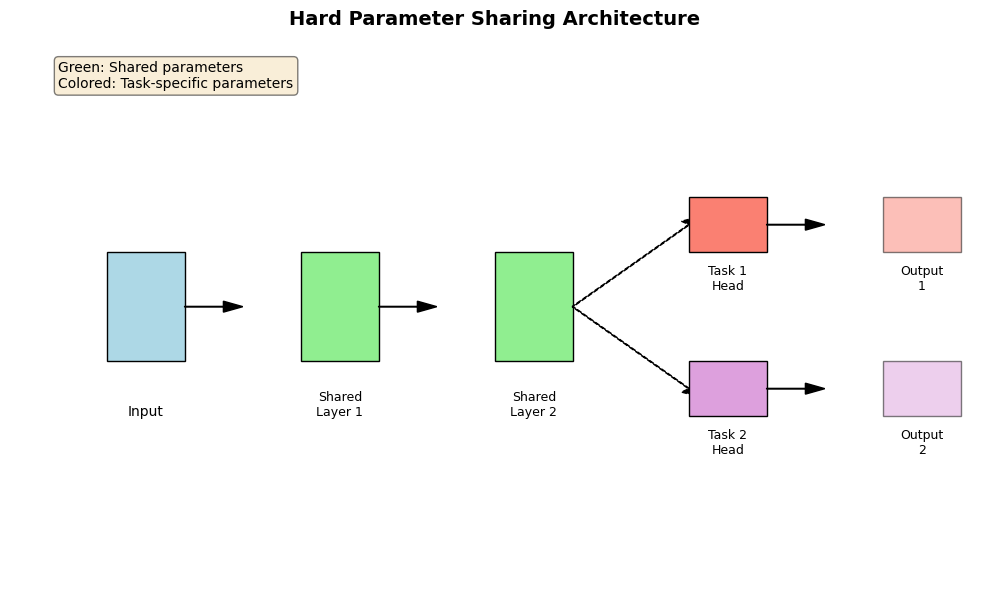

In [7]:
def visualize_hard_sharing():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')
    
    # Draw layers
    layer_positions = [0.1, 0.3, 0.5, 0.7, 0.9]
    
    # Input
    ax.add_patch(plt.Rectangle((layer_positions[0], 0.4), 0.08, 0.2, 
                                facecolor='lightblue', edgecolor='black'))
    ax.text(layer_positions[0] + 0.04, 0.3, 'Input', ha='center', fontsize=10)
    
    # Shared layers
    for i in range(1, 3):
        ax.add_patch(plt.Rectangle((layer_positions[i], 0.4), 0.08, 0.2, 
                                    facecolor='lightgreen', edgecolor='black'))
        ax.text(layer_positions[i] + 0.04, 0.3, f'Shared\nLayer {i}', 
                ha='center', fontsize=9)
        # Arrow
        ax.arrow(layer_positions[i-1] + 0.08, 0.5, 0.04, 0, 
                head_width=0.02, head_length=0.02, fc='black')
    
    # Task heads
    tasks = ['Task 1', 'Task 2']
    colors = ['salmon', 'plum']
    y_positions = [0.65, 0.35]
    
    for task_idx, (task, color, y_pos) in enumerate(zip(tasks, colors, y_positions)):
        # Arrow from shared to task head
        ax.arrow(layer_positions[2] + 0.08, 0.5, 
                layer_positions[3] - layer_positions[2] - 0.08, y_pos - 0.5,
                head_width=0.02, head_length=0.02, fc='black', linestyle='--')
        
        # Task head
        ax.add_patch(plt.Rectangle((layer_positions[3], y_pos - 0.05), 0.08, 0.1, 
                                    facecolor=color, edgecolor='black'))
        ax.text(layer_positions[3] + 0.04, y_pos - 0.12, f'{task}\nHead', 
                ha='center', fontsize=9)
        
        # Output
        ax.add_patch(plt.Rectangle((layer_positions[4], y_pos - 0.05), 0.08, 0.1, 
                                    facecolor=color, edgecolor='black', alpha=0.5))
        ax.text(layer_positions[4] + 0.04, y_pos - 0.12, f'Output\n{task_idx + 1}', 
                ha='center', fontsize=9)
        
        # Arrow to output
        ax.arrow(layer_positions[3] + 0.08, y_pos, 0.04, 0,
                head_width=0.02, head_length=0.02, fc='black')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title('Hard Parameter Sharing Architecture', fontsize=14, fontweight='bold')
    
    # Legend
    ax.text(0.05, 0.9, 'Green: Shared parameters\nColored: Task-specific parameters', 
            fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

visualize_hard_sharing()

### Soft Parameter Sharing

**Soft parameter sharing** gives each task its own parameters but encourages them to be similar:
- **Each task has its own network** (separate parameters)
- **Regularization term** penalizes differences between task parameters
- **Benefit**: Tasks can diverge if needed, more flexible
- **Risk**: More parameters, less regularization

The regularization loss encourages similarity:
$$L_{reg} = \sum_{i,j} ||\theta_i - \theta_j||^2$$

where $\theta_i$ and $\theta_j$ are parameters for tasks $i$ and $j$.

### Implement soft parameter sharing

In [8]:
class SoftSharingModel(nn.Module):
    """Multi-task model with soft parameter sharing."""
    
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1):
        super().__init__()
        # Separate networks for each task
        self.net_task1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        self.net_task2 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        y1 = self.net_task1(x)
        y2 = self.net_task2(x)
        return y1, y2
    
    def parameter_distance_loss(self, lambda_reg=0.01):
        """Compute regularization loss to encourage parameter similarity."""
        loss = 0.0
        # Compare corresponding layers
        params1 = list(self.net_task1.parameters())
        params2 = list(self.net_task2.parameters())
        
        for p1, p2 in zip(params1, params2):
            loss += torch.sum((p1 - p2) ** 2)
        
        return lambda_reg * loss

model_soft = SoftSharingModel().to(device)
print(f"Soft sharing model parameters: {count_parameters(model_soft):,}")

# Compute initial parameter distance
initial_distance = model_soft.parameter_distance_loss(lambda_reg=1.0)
print(f"Initial parameter distance: {initial_distance.item():.4f}")

Soft sharing model parameters: 2,370


Initial parameter distance: 51.9607


### Key Insight: Hard vs Soft Sharing

**Hard sharing:**
- Fewer parameters (more efficient)
- Stronger regularization (less overfitting)
- Risk of negative transfer if tasks differ
- **Use when:** Tasks are closely related

**Soft sharing:**
- More parameters (less efficient)
- Weaker regularization (more flexible)
- Can adapt to task differences
- **Use when:** Task relationships are uncertain

**Most practical MTL uses hard sharing** due to its efficiency and strong empirical performance.

## 4. Loss Balancing: The Critical Challenge

### The Problem: Different Loss Scales

When training on multiple tasks, each task has its own loss. The total loss is typically:

$$L_{total} = \sum_{i=1}^T w_i L_i$$

where $w_i$ are task weights and $L_i$ are individual task losses.

**The challenge:** Different tasks have different loss scales!
- Task 1 loss might be ~0.1
- Task 2 loss might be ~10.0

Without proper weighting, the model will focus on the task with larger loss magnitudes, ignoring others.

### Demonstrate the loss scale problem

In [9]:
def train_mtl_naive(model, train_loader, val_loader, epochs=50, lr=0.01):
    """Train multi-task model with naive loss summation (no balancing)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss1': [], 'train_loss2': [], 'val_loss1': [], 'val_loss2': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss1_total, train_loss2_total = 0.0, 0.0
        
        for x, y1, y2 in train_loader:
            x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
            
            optimizer.zero_grad()
            pred1, pred2 = model(x)
            
            # Individual losses (note: different scales!)
            loss1 = F.mse_loss(pred1, y1)
            loss2 = F.mse_loss(pred2, y2)
            
            # Naive approach: just sum them
            total_loss = loss1 + loss2
            
            total_loss.backward()
            optimizer.step()
            
            train_loss1_total += loss1.item()
            train_loss2_total += loss2.item()
        
        # Validation
        model.eval()
        val_loss1_total, val_loss2_total = 0.0, 0.0
        
        with torch.no_grad():
            for x, y1, y2 in val_loader:
                x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
                pred1, pred2 = model(x)
                
                val_loss1_total += F.mse_loss(pred1, y1).item()
                val_loss2_total += F.mse_loss(pred2, y2).item()
        
        # Record history
        history['train_loss1'].append(train_loss1_total / len(train_loader))
        history['train_loss2'].append(train_loss2_total / len(train_loader))
        history['val_loss1'].append(val_loss1_total / len(val_loader))
        history['val_loss2'].append(val_loss2_total / len(val_loader))
    
    return history

# Train with naive approach
model_naive = MultiTaskModel().to(device)
history_naive = train_mtl_naive(model_naive, train_loader, val_loader, epochs=50)

print("Training complete. Plotting loss curves...")

Training complete. Plotting loss curves...


### Visualize the imbalanced learning

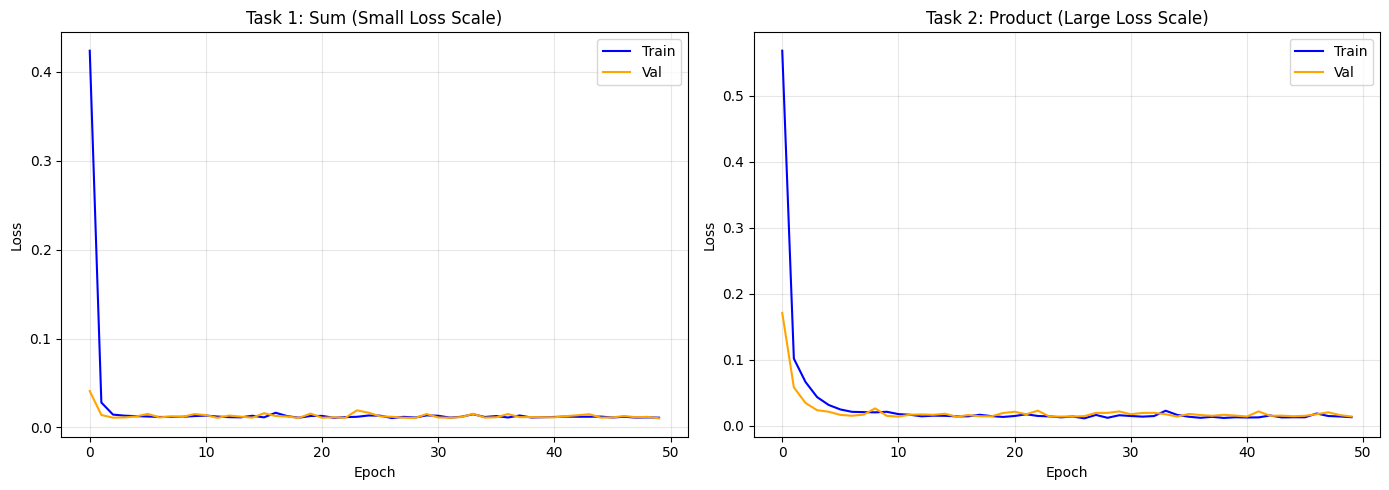

Final Task 1 loss: 0.0102
Final Task 2 loss: 0.0139
Loss ratio (Task2 / Task1): 1.36x


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Task 1 loss
axes[0].plot(history_naive['train_loss1'], label='Train', color='blue')
axes[0].plot(history_naive['val_loss1'], label='Val', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Task 1: Sum (Small Loss Scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Task 2 loss
axes[1].plot(history_naive['train_loss2'], label='Train', color='blue')
axes[1].plot(history_naive['val_loss2'], label='Val', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Task 2: Product (Large Loss Scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Task 1 loss: {history_naive['val_loss1'][-1]:.4f}")
print(f"Final Task 2 loss: {history_naive['val_loss2'][-1]:.4f}")
print(f"Loss ratio (Task2 / Task1): {history_naive['val_loss2'][-1] / history_naive['val_loss1'][-1]:.2f}x")

### Observation: Unbalanced Learning

Notice how Task 2 (product) has much larger loss values than Task 1 (sum). This means:
- **Gradients from Task 2 dominate** the optimization
- **Task 1 gets less attention** during training
- **Result:** Suboptimal performance on both tasks

We need a way to **balance the contribution** of each task to the overall loss.

### Solution 1: Manual Weighting

The simplest approach: manually set task weights to balance loss scales.

$$L_{total} = w_1 L_1 + w_2 L_2$$

**How to choose weights?**
- Monitor initial loss values
- Set weights inversely proportional to loss scales
- Requires manual tuning (trial and error)

### Implement manual weighting

In [11]:
def train_mtl_weighted(model, train_loader, val_loader, weights=(1.0, 1.0), epochs=50, lr=0.01):
    """Train multi-task model with manual task weights."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss1': [], 'train_loss2': [], 'val_loss1': [], 'val_loss2': []}
    w1, w2 = weights
    
    for epoch in range(epochs):
        model.train()
        train_loss1_total, train_loss2_total = 0.0, 0.0
        
        for x, y1, y2 in train_loader:
            x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
            
            optimizer.zero_grad()
            pred1, pred2 = model(x)
            
            loss1 = F.mse_loss(pred1, y1)
            loss2 = F.mse_loss(pred2, y2)
            
            # Weighted sum
            total_loss = w1 * loss1 + w2 * loss2
            
            total_loss.backward()
            optimizer.step()
            
            train_loss1_total += loss1.item()
            train_loss2_total += loss2.item()
        
        model.eval()
        val_loss1_total, val_loss2_total = 0.0, 0.0
        
        with torch.no_grad():
            for x, y1, y2 in val_loader:
                x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
                pred1, pred2 = model(x)
                
                val_loss1_total += F.mse_loss(pred1, y1).item()
                val_loss2_total += F.mse_loss(pred2, y2).item()
        
        history['train_loss1'].append(train_loss1_total / len(train_loader))
        history['train_loss2'].append(train_loss2_total / len(train_loader))
        history['val_loss1'].append(val_loss1_total / len(val_loader))
        history['val_loss2'].append(val_loss2_total / len(val_loader))
    
    return history

# Try different weightings
model_weighted = MultiTaskModel().to(device)
# Weight task 2 less since it has larger loss values
history_weighted = train_mtl_weighted(model_weighted, train_loader, val_loader, 
                                     weights=(1.0, 0.1), epochs=50)

print(f"Final Task 1 loss (weighted): {history_weighted['val_loss1'][-1]:.4f}")
print(f"Final Task 2 loss (weighted): {history_weighted['val_loss2'][-1]:.4f}")

Final Task 1 loss (weighted): 0.0128
Final Task 2 loss (weighted): 0.0192


### Solution 2: Uncertainty-Based Weighting

A more principled approach from [Kendall et al., 2018](https://arxiv.org/abs/1705.07115): Learn task weights based on **homoscedastic uncertainty**.

Instead of manually setting weights, we learn them as parameters:

$$L_{total} = \sum_{i=1}^T \frac{1}{2\sigma_i^2} L_i + \log \sigma_i$$

where $\sigma_i$ is a learned parameter representing the uncertainty of task $i$.

**Intuition:**
- Tasks with high uncertainty ($\sigma_i$ large) contribute less to the loss
- The $\log \sigma_i$ term prevents $\sigma_i$ from growing unbounded
- The model automatically balances tasks during training

### Implement uncertainty-based weighting

In [12]:
class UncertaintyWeightedMTL(nn.Module):
    """Multi-task model with learned uncertainty-based weights."""
    
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1, num_tasks=2):
        super().__init__()
        # Shared encoder
        self.shared_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        # Task heads
        self.head_task1 = nn.Linear(hidden_dim, output_dim)
        self.head_task2 = nn.Linear(hidden_dim, output_dim)
        
        # Learned uncertainty parameters (log variance)
        self.log_vars = nn.Parameter(torch.zeros(num_tasks))
    
    def forward(self, x):
        features = self.shared_encoder(x)
        y1 = self.head_task1(features)
        y2 = self.head_task2(features)
        return y1, y2
    
    def compute_loss(self, pred1, pred2, y1, y2):
        """Compute uncertainty-weighted loss."""
        # Task losses
        loss1 = F.mse_loss(pred1, y1)
        loss2 = F.mse_loss(pred2, y2)
        
        # Uncertainty weighting
        precision1 = torch.exp(-self.log_vars[0])
        precision2 = torch.exp(-self.log_vars[1])
        
        total_loss = precision1 * loss1 + self.log_vars[0] + \
                    precision2 * loss2 + self.log_vars[1]
        
        return total_loss, loss1, loss2

model_uncertainty = UncertaintyWeightedMTL().to(device)
print(f"Initial log variances: {model_uncertainty.log_vars.data}")
print(f"Initial weights (1/2σ²): Task1={torch.exp(-model_uncertainty.log_vars[0]).item():.4f}, "
      f"Task2={torch.exp(-model_uncertainty.log_vars[1]).item():.4f}")

Initial log variances: tensor([0., 0.], device='mps:0')
Initial weights (1/2σ²): Task1=1.0000, Task2=1.0000


### Train with uncertainty weighting

In [13]:
def train_mtl_uncertainty(model, train_loader, val_loader, epochs=50, lr=0.01):
    """Train multi-task model with uncertainty-based weighting."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {
        'train_loss1': [], 'train_loss2': [], 
        'val_loss1': [], 'val_loss2': [],
        'weight1': [], 'weight2': []
    }
    
    for epoch in range(epochs):
        model.train()
        train_loss1_total, train_loss2_total = 0.0, 0.0
        
        for x, y1, y2 in train_loader:
            x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
            
            optimizer.zero_grad()
            pred1, pred2 = model(x)
            
            total_loss, loss1, loss2 = model.compute_loss(pred1, pred2, y1, y2)
            
            total_loss.backward()
            optimizer.step()
            
            train_loss1_total += loss1.item()
            train_loss2_total += loss2.item()
        
        model.eval()
        val_loss1_total, val_loss2_total = 0.0, 0.0
        
        with torch.no_grad():
            for x, y1, y2 in val_loader:
                x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
                pred1, pred2 = model(x)
                
                val_loss1_total += F.mse_loss(pred1, y1).item()
                val_loss2_total += F.mse_loss(pred2, y2).item()
        
        # Record history
        history['train_loss1'].append(train_loss1_total / len(train_loader))
        history['train_loss2'].append(train_loss2_total / len(train_loader))
        history['val_loss1'].append(val_loss1_total / len(val_loader))
        history['val_loss2'].append(val_loss2_total / len(val_loader))
        
        # Record learned weights
        with torch.no_grad():
            history['weight1'].append(torch.exp(-model.log_vars[0]).item())
            history['weight2'].append(torch.exp(-model.log_vars[1]).item())
    
    return history

history_uncertainty = train_mtl_uncertainty(model_uncertainty, train_loader, val_loader, epochs=50)

print(f"\nFinal log variances: {model_uncertainty.log_vars.data}")
print(f"Final weights: Task1={history_uncertainty['weight1'][-1]:.4f}, "
      f"Task2={history_uncertainty['weight2'][-1]:.4f}")
print(f"Weight ratio (Task1/Task2): {history_uncertainty['weight1'][-1] / history_uncertainty['weight2'][-1]:.2f}x")


Final log variances: tensor([-4.3998, -4.2753], device='mps:0')
Final weights: Task1=81.4379, Task2=71.9032
Weight ratio (Task1/Task2): 1.13x


### Visualize how weights evolved during training

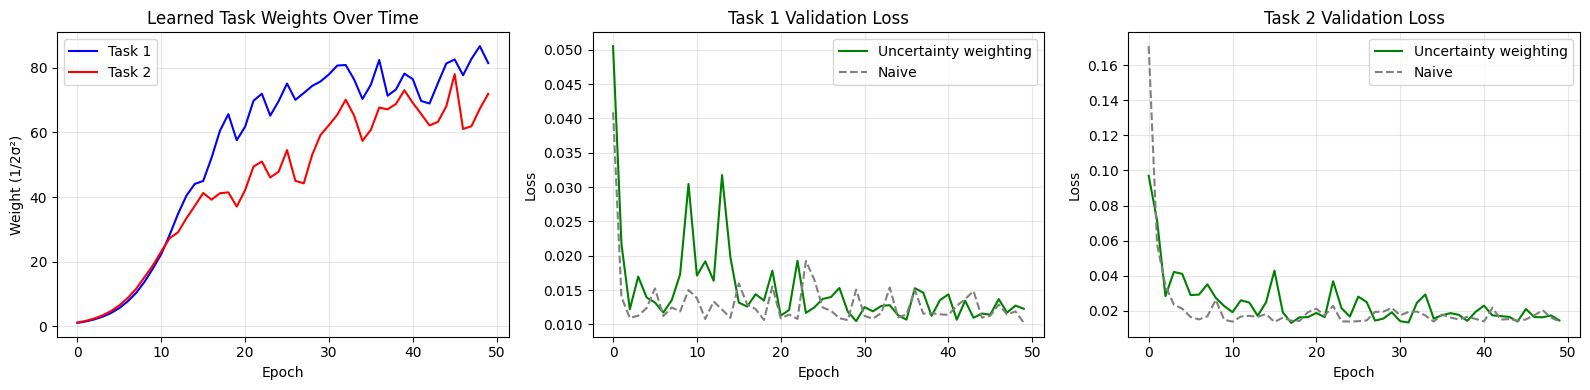

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Weight evolution
axes[0].plot(history_uncertainty['weight1'], label='Task 1', color='blue')
axes[0].plot(history_uncertainty['weight2'], label='Task 2', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weight (1/2σ²)')
axes[0].set_title('Learned Task Weights Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Task 1 loss
axes[1].plot(history_uncertainty['val_loss1'], label='Uncertainty weighting', color='green')
axes[1].plot(history_naive['val_loss1'], label='Naive', color='gray', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Task 1 Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Task 2 loss
axes[2].plot(history_uncertainty['val_loss2'], label='Uncertainty weighting', color='green')
axes[2].plot(history_naive['val_loss2'], label='Naive', color='gray', linestyle='--')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Task 2 Validation Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight: Automatic Balancing

Notice how:
1. **Task weights adapt during training** - The model learns to weight tasks appropriately
2. **Task 2 gets lower weight** - Because it has larger loss values
3. **Both tasks improve** - Unlike naive weighting where one task dominates

This automatic balancing is why uncertainty weighting is widely used in practice.

## 5. Vision Multi-Task Learning

### Practical Example: Multi-Task Image Classification

Let's build a real multi-task vision model using CIFAR-10. We'll train on three tasks:
1. **Main classification**: 10-way classification (airplane, car, bird, etc.)
2. **Coarse classification**: 2-way classification (vehicle vs animal)
3. **Color prediction**: Predict dominant color channel (R, G, or B)

These tasks share visual features (edges, textures, shapes) but have different objectives.

### Load and prepare CIFAR-10 dataset

In [15]:
# Create multi-task CIFAR-10 dataset
class MultiTaskCIFAR10(Dataset):
    """CIFAR-10 with multiple task labels."""
    
    def __init__(self, train=True):
        # Define transforms
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
        ])
        
        # Load CIFAR-10
        self.dataset = datasets.CIFAR10(
            root='./data', 
            train=train, 
            download=True,
            transform=transform
        )
        
        # Define coarse labels (0: vehicle, 1: animal)
        # CIFAR-10 classes: 0-airplane, 1-car, 2-bird, 3-cat, 4-deer, 
        #                   5-dog, 6-frog, 7-horse, 8-ship, 9-truck
        self.coarse_mapping = {
            0: 0, 1: 0, 8: 0, 9: 0,  # vehicles
            2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1  # animals
        }
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        
        # Task 1: Fine-grained class (0-9)
        fine_label = label
        
        # Task 2: Coarse class (vehicle vs animal)
        coarse_label = self.coarse_mapping[label]
        
        # Task 3: Dominant color (synthetic task for demonstration)
        # Compute which color channel has highest mean
        color_means = img.mean(dim=(1, 2))  # [R, G, B]
        dominant_color = torch.argmax(color_means).item()
        
        return img, fine_label, coarse_label, dominant_color

# Create datasets (use subset for faster training in notebook)
train_dataset_full = MultiTaskCIFAR10(train=True)
val_dataset_full = MultiTaskCIFAR10(train=False)

# Use subset for demonstration
train_subset_indices = torch.randperm(len(train_dataset_full))[:5000]
val_subset_indices = torch.randperm(len(val_dataset_full))[:1000]

train_dataset = torch.utils.data.Subset(train_dataset_full, train_subset_indices)
val_dataset = torch.utils.data.Subset(val_dataset_full, val_subset_indices)

# Create data loaders
train_loader_vision = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader_vision = DataLoader(val_dataset, batch_size=64)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Show a sample
img, fine, coarse, color = train_dataset_full[0]
print(f"\nSample: Fine class={fine}, Coarse class={'vehicle' if coarse == 0 else 'animal'}, "
      f"Dominant color={'R' if color == 0 else 'G' if color == 1 else 'B'}")

Training samples: 5000
Validation samples: 1000

Sample: Fine class=6, Coarse class=animal, Dominant color=R


### Build multi-task CNN architecture

In [16]:
class MultiTaskCNN(nn.Module):
    """Multi-task CNN for image classification with uncertainty weighting."""
    
    def __init__(self, num_classes_fine=10, num_classes_coarse=2, num_colors=3):
        super().__init__()
        
        # Shared convolutional encoder
        self.shared_encoder = nn.Sequential(
            # Conv block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Conv block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Conv block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        # Task-specific heads
        self.head_fine = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes_fine)
        )
        
        self.head_coarse = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes_coarse)
        )
        
        self.head_color = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_colors)
        )
        
        # Learned uncertainty parameters for 3 tasks
        self.log_vars = nn.Parameter(torch.zeros(3))
    
    def forward(self, x):
        # Shared features
        features = self.shared_encoder(x)
        
        # Task-specific predictions
        out_fine = self.head_fine(features)
        out_coarse = self.head_coarse(features)
        out_color = self.head_color(features)
        
        return out_fine, out_coarse, out_color
    
    def compute_loss(self, out_fine, out_coarse, out_color, y_fine, y_coarse, y_color):
        """Compute uncertainty-weighted multi-task loss."""
        # Individual task losses
        loss_fine = F.cross_entropy(out_fine, y_fine)
        loss_coarse = F.cross_entropy(out_coarse, y_coarse)
        loss_color = F.cross_entropy(out_color, y_color)
        
        # Uncertainty weighting
        precision_fine = torch.exp(-self.log_vars[0])
        precision_coarse = torch.exp(-self.log_vars[1])
        precision_color = torch.exp(-self.log_vars[2])
        
        total_loss = (precision_fine * loss_fine + self.log_vars[0] +
                     precision_coarse * loss_coarse + self.log_vars[1] +
                     precision_color * loss_color + self.log_vars[2])
        
        return total_loss, loss_fine, loss_coarse, loss_color

model_vision = MultiTaskCNN().to(device)
print(f"Total parameters: {count_parameters(model_vision):,}")

# Count shared vs task-specific parameters
shared_params = sum(p.numel() for p in model_vision.shared_encoder.parameters())
task_params = sum(p.numel() for p in model_vision.head_fine.parameters()) + \
              sum(p.numel() for p in model_vision.head_coarse.parameters()) + \
              sum(p.numel() for p in model_vision.head_color.parameters())

print(f"Shared parameters: {shared_params:,} ({shared_params / count_parameters(model_vision) * 100:.1f}%)")
print(f"Task-specific parameters: {task_params:,} ({task_params / count_parameters(model_vision) * 100:.1f}%)")

Total parameters: 1,061,042
Shared parameters: 140,064 (13.2%)
Task-specific parameters: 920,975 (86.8%)


### Train the multi-task vision model

In [17]:
def train_vision_mtl(model, train_loader, val_loader, epochs=10, lr=0.001):
    """Train multi-task vision model."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {
        'train_loss_fine': [], 'train_loss_coarse': [], 'train_loss_color': [],
        'val_loss_fine': [], 'val_loss_coarse': [], 'val_loss_color': [],
        'val_acc_fine': [], 'val_acc_coarse': [], 'val_acc_color': [],
        'weights': []
    }
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = {'fine': 0.0, 'coarse': 0.0, 'color': 0.0}
        
        for img, y_fine, y_coarse, y_color in train_loader:
            img = img.to(device)
            y_fine = y_fine.to(device)
            y_coarse = y_coarse.to(device)
            y_color = y_color.to(device)
            
            optimizer.zero_grad()
            out_fine, out_coarse, out_color = model(img)
            
            total_loss, loss_fine, loss_coarse, loss_color = model.compute_loss(
                out_fine, out_coarse, out_color, y_fine, y_coarse, y_color
            )
            
            total_loss.backward()
            optimizer.step()
            
            train_losses['fine'] += loss_fine.item()
            train_losses['coarse'] += loss_coarse.item()
            train_losses['color'] += loss_color.item()
        
        # Validation
        model.eval()
        val_losses = {'fine': 0.0, 'coarse': 0.0, 'color': 0.0}
        val_correct = {'fine': 0, 'coarse': 0, 'color': 0}
        val_total = 0
        
        with torch.no_grad():
            for img, y_fine, y_coarse, y_color in val_loader:
                img = img.to(device)
                y_fine = y_fine.to(device)
                y_coarse = y_coarse.to(device)
                y_color = y_color.to(device)
                
                out_fine, out_coarse, out_color = model(img)
                
                val_losses['fine'] += F.cross_entropy(out_fine, y_fine).item()
                val_losses['coarse'] += F.cross_entropy(out_coarse, y_coarse).item()
                val_losses['color'] += F.cross_entropy(out_color, y_color).item()
                
                val_correct['fine'] += (out_fine.argmax(1) == y_fine).sum().item()
                val_correct['coarse'] += (out_coarse.argmax(1) == y_coarse).sum().item()
                val_correct['color'] += (out_color.argmax(1) == y_color).sum().item()
                val_total += img.size(0)
        
        # Record history
        for task in ['fine', 'coarse', 'color']:
            history[f'train_loss_{task}'].append(train_losses[task] / len(train_loader))
            history[f'val_loss_{task}'].append(val_losses[task] / len(val_loader))
            history[f'val_acc_{task}'].append(val_correct[task] / val_total * 100)
        
        # Record weights
        with torch.no_grad():
            weights = [torch.exp(-lv).item() for lv in model.log_vars]
            history['weights'].append(weights)
        
        scheduler.step()
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs}:")
            print(f"  Fine: Loss={history['val_loss_fine'][-1]:.4f}, Acc={history['val_acc_fine'][-1]:.2f}%")
            print(f"  Coarse: Loss={history['val_loss_coarse'][-1]:.4f}, Acc={history['val_acc_coarse'][-1]:.2f}%")
            print(f"  Color: Loss={history['val_loss_color'][-1]:.4f}, Acc={history['val_acc_color'][-1]:.2f}%")
            print(f"  Weights: {weights}")
    
    return history

print("Training multi-task vision model...")
history_vision = train_vision_mtl(model_vision, train_loader_vision, val_loader_vision, epochs=10)
print("\nTraining complete!")

Training multi-task vision model...


Epoch 2/10:
  Fine: Loss=1.5673, Acc=42.80%
  Coarse: Loss=0.2800, Acc=87.80%
  Color: Loss=0.2798, Acc=87.60%
  Weights: [0.8889621496200562, 1.169898509979248, 1.1764601469039917]


Epoch 4/10:
  Fine: Loss=1.4677, Acc=45.80%
  Coarse: Loss=0.2493, Acc=89.50%
  Color: Loss=0.2449, Acc=89.40%
  Weights: [0.8368278741836548, 1.3468308448791504, 1.3580505847930908]


Epoch 6/10:
  Fine: Loss=1.3540, Acc=49.00%
  Coarse: Loss=0.2131, Acc=91.40%
  Color: Loss=0.1682, Acc=92.70%
  Weights: [0.8205920457839966, 1.4810571670532227, 1.4923120737075806]


Epoch 8/10:
  Fine: Loss=1.2793, Acc=53.00%
  Coarse: Loss=0.1982, Acc=92.50%
  Color: Loss=0.1679, Acc=92.70%
  Weights: [0.8225732445716858, 1.5508065223693848, 1.5596120357513428]


Epoch 10/10:
  Fine: Loss=1.2616, Acc=52.40%
  Coarse: Loss=0.1867, Acc=93.00%
  Color: Loss=0.1336, Acc=94.40%
  Weights: [0.824878454208374, 1.5669419765472412, 1.575608253479004]

Training complete!


### Visualize vision MTL results

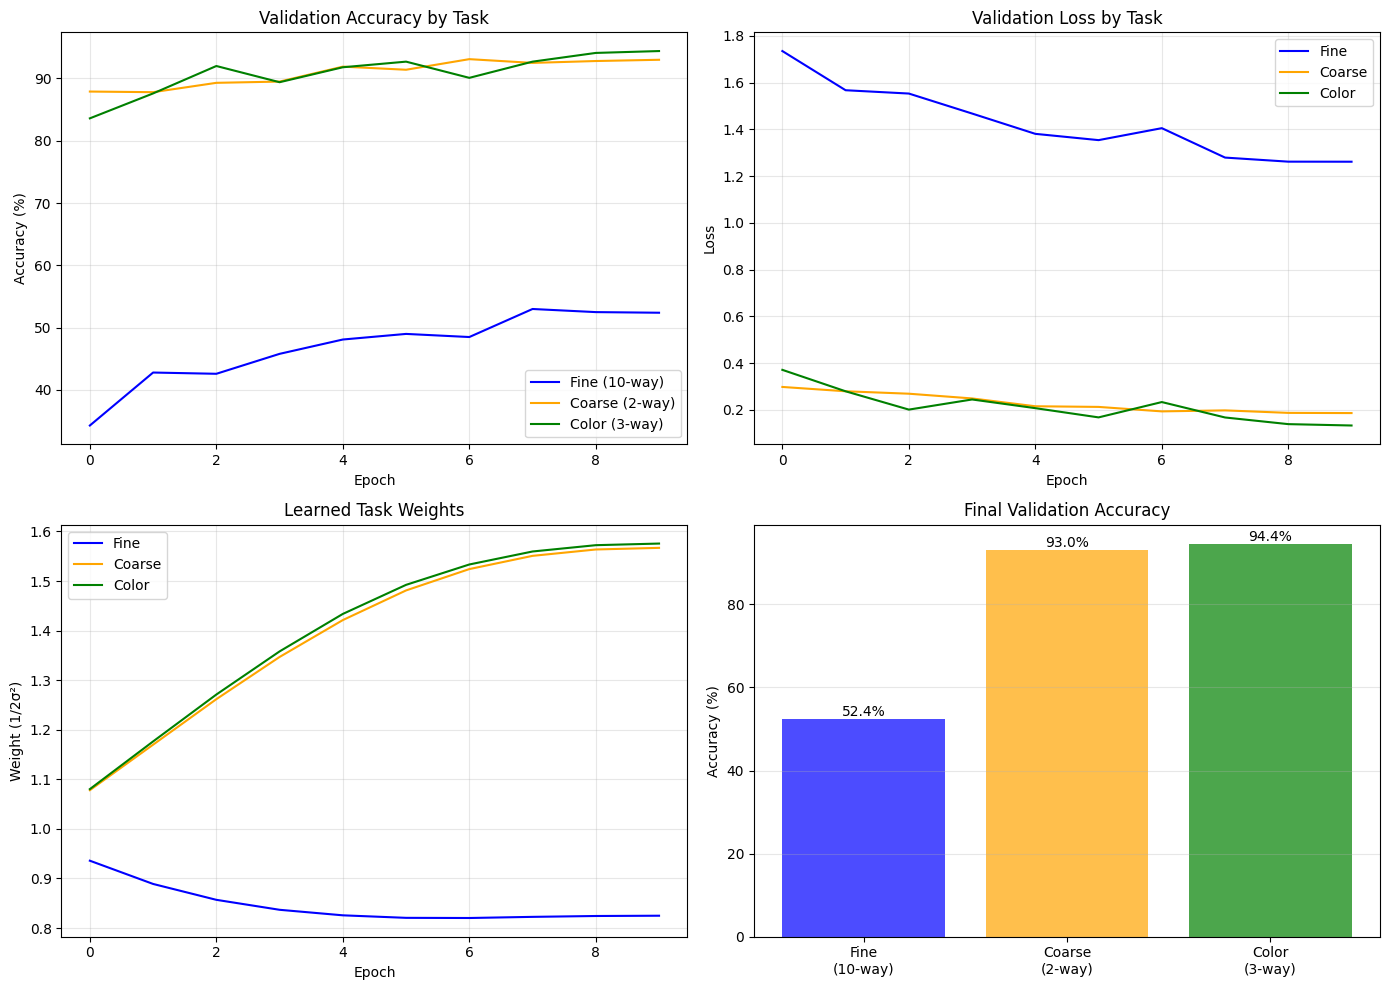


Final Results:
Fine-grained classification: 52.40%
Coarse classification: 93.00%
Color prediction: 94.40%


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracies
axes[0, 0].plot(history_vision['val_acc_fine'], label='Fine (10-way)', color='blue')
axes[0, 0].plot(history_vision['val_acc_coarse'], label='Coarse (2-way)', color='orange')
axes[0, 0].plot(history_vision['val_acc_color'], label='Color (3-way)', color='green')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Validation Accuracy by Task')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Losses
axes[0, 1].plot(history_vision['val_loss_fine'], label='Fine', color='blue')
axes[0, 1].plot(history_vision['val_loss_coarse'], label='Coarse', color='orange')
axes[0, 1].plot(history_vision['val_loss_color'], label='Color', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Validation Loss by Task')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learned weights
weights_array = np.array(history_vision['weights'])
axes[1, 0].plot(weights_array[:, 0], label='Fine', color='blue')
axes[1, 0].plot(weights_array[:, 1], label='Coarse', color='orange')
axes[1, 0].plot(weights_array[:, 2], label='Color', color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Weight (1/2σ²)')
axes[1, 0].set_title('Learned Task Weights')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Final performance comparison
tasks = ['Fine\n(10-way)', 'Coarse\n(2-way)', 'Color\n(3-way)']
accs = [history_vision['val_acc_fine'][-1], 
        history_vision['val_acc_coarse'][-1],
        history_vision['val_acc_color'][-1]]
colors = ['blue', 'orange', 'green']

bars = axes[1, 1].bar(tasks, accs, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Final Validation Accuracy')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accs):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{acc:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nFinal Results:")
print(f"Fine-grained classification: {history_vision['val_acc_fine'][-1]:.2f}%")
print(f"Coarse classification: {history_vision['val_acc_coarse'][-1]:.2f}%")
print(f"Color prediction: {history_vision['val_acc_color'][-1]:.2f}%")

### Key Observations from Vision MTL

1. **Different task difficulties**: The coarse task (vehicle vs animal) is easier than fine-grained classification, reflected in higher accuracy
2. **Weight adaptation**: The model learned to weight tasks differently based on their difficulty and loss scales
3. **Shared representations**: All tasks benefit from the shared convolutional encoder that learns visual features
4. **Parameter efficiency**: We trained 3 tasks with fewer parameters than 3 separate models would require

## 6. Task Relationships and Transfer

### Positive vs Negative Transfer

Not all task combinations work well together:

**Positive transfer:**
- Related tasks help each other
- Shared features are useful for all tasks
- Example: Object detection + segmentation (both need edge detection)

**Negative transfer:**
- Unrelated tasks hurt each other
- Shared features become a compromise that helps neither task
- Example: Sentiment analysis + image classification (no shared structure)

**How to detect negative transfer:**
- Compare multi-task performance to single-task baselines
- If multi-task model performs worse, negative transfer may be occurring

### Measure task relationships through gradient analysis

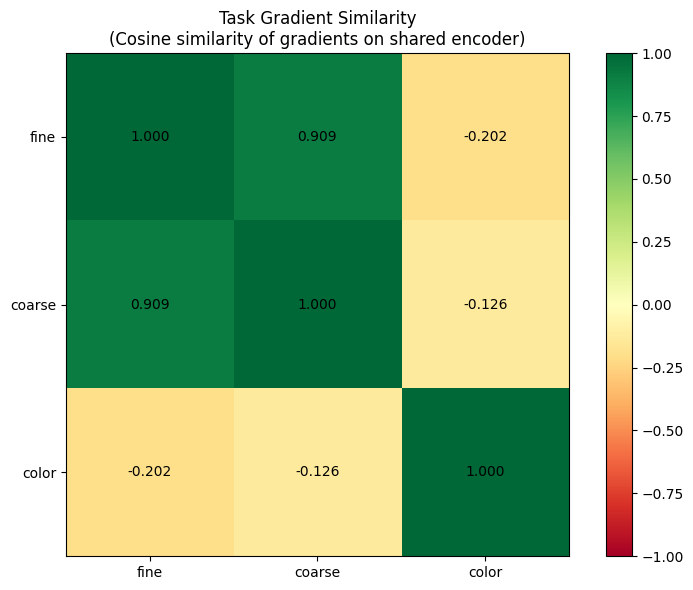


Interpretation:
- Values close to +1: Tasks have aligned gradients (positive transfer)
- Values close to 0: Tasks are independent
- Values close to -1: Tasks have conflicting gradients (negative transfer)


In [19]:
def compute_gradient_similarity(model, dataloader, device):
    """Compute cosine similarity between task gradients."""
    model.eval()
    
    # Get a batch
    img, y_fine, y_coarse, y_color = next(iter(dataloader))
    img = img.to(device)
    y_fine = y_fine.to(device)
    y_coarse = y_coarse.to(device)
    y_color = y_color.to(device)
    
    # Compute gradients for each task separately
    gradients = {}
    
    for task_name, task_idx, y_true in [('fine', 0, y_fine), 
                                          ('coarse', 1, y_coarse), 
                                          ('color', 2, y_color)]:
        model.zero_grad()
        out_fine, out_coarse, out_color = model(img)
        
        # Get loss for this task
        if task_idx == 0:
            loss = F.cross_entropy(out_fine, y_true)
        elif task_idx == 1:
            loss = F.cross_entropy(out_coarse, y_true)
        else:
            loss = F.cross_entropy(out_color, y_true)
        
        loss.backward()
        
        # Collect gradients from shared encoder
        task_grads = []
        for param in model.shared_encoder.parameters():
            if param.grad is not None:
                task_grads.append(param.grad.view(-1))
        
        gradients[task_name] = torch.cat(task_grads)
    
    # Compute cosine similarities
    tasks = ['fine', 'coarse', 'color']
    similarities = np.zeros((3, 3))
    
    for i, task1 in enumerate(tasks):
        for j, task2 in enumerate(tasks):
            if task1 in gradients and task2 in gradients:
                sim = F.cosine_similarity(
                    gradients[task1].unsqueeze(0),
                    gradients[task2].unsqueeze(0)
                ).item()
                similarities[i, j] = sim
    
    return similarities, tasks

# Compute gradient similarities
similarities, task_names = compute_gradient_similarity(model_vision, val_loader_vision, device)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(similarities, cmap='RdYlGn', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(task_names)))
ax.set_yticks(np.arange(len(task_names)))
ax.set_xticklabels(task_names)
ax.set_yticklabels(task_names)

# Add text annotations
for i in range(len(task_names)):
    for j in range(len(task_names)):
        text = ax.text(j, i, f'{similarities[i, j]:.3f}',
                      ha="center", va="center", color="black")

ax.set_title('Task Gradient Similarity\n(Cosine similarity of gradients on shared encoder)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Values close to +1: Tasks have aligned gradients (positive transfer)")
print("- Values close to 0: Tasks are independent")
print("- Values close to -1: Tasks have conflicting gradients (negative transfer)")

### Key Insight: Task Compatibility

The gradient similarity matrix shows how compatible tasks are:
- **High similarity (> 0.5)**: Tasks want similar updates to shared parameters (good for MTL)
- **Low similarity (< 0)**: Tasks want conflicting updates (risk of negative transfer)

This analysis helps decide which tasks to combine in MTL.

## 7. Advanced Architecture: Cross-Stitch Networks

### Beyond Simple Sharing

**Cross-stitch networks** allow tasks to share information at multiple layers, not just at the input:

- Each task has its own network path
- At each layer, tasks can exchange information via learned linear combinations
- More flexible than hard sharing, less redundant than soft sharing

**Cross-stitch unit:**
$$
\begin{bmatrix}
h_1^{(l+1)} \\
h_2^{(l+1)}
\end{bmatrix}
=
\begin{bmatrix}
\alpha_{11} & \alpha_{12} \\
\alpha_{21} & \alpha_{22}
\end{bmatrix}
\begin{bmatrix}
h_1^{(l)} \\
h_2^{(l)}
\end{bmatrix}
$$

where $\alpha_{ij}$ are learned parameters controlling information flow from task $j$ to task $i$.

### Implement a simple cross-stitch network

In [20]:
class CrossStitchUnit(nn.Module):
    """Cross-stitch unit for combining task representations."""
    
    def __init__(self, num_tasks=2):
        super().__init__()
        # Learnable linear combination matrix
        self.alpha = nn.Parameter(torch.eye(num_tasks))
    
    def forward(self, *task_features):
        """Combine features from multiple tasks.
        
        Args:
            task_features: Tuple of tensors (batch_size, channels, height, width)
        
        Returns:
            Tuple of combined features for each task
        """
        # Stack task features: (num_tasks, batch_size, channels, height, width)
        stacked = torch.stack(task_features, dim=0)
        
        # Apply cross-stitch: weighted combination across tasks
        # alpha: (num_tasks, num_tasks)
        # stacked: (num_tasks, batch_size, ...)
        combined = torch.einsum('ij,j...->i...', self.alpha, stacked)
        
        # Return tuple of combined features
        return tuple(combined[i] for i in range(len(task_features)))

class CrossStitchNetwork(nn.Module):
    """Simple cross-stitch network for 2 tasks."""
    
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1):
        super().__init__()
        
        # Task-specific layers
        self.layer1_task1 = nn.Linear(input_dim, hidden_dim)
        self.layer1_task2 = nn.Linear(input_dim, hidden_dim)
        
        # Cross-stitch unit after first layer
        self.cross_stitch1 = CrossStitchUnit(num_tasks=2)
        
        self.layer2_task1 = nn.Linear(hidden_dim, hidden_dim)
        self.layer2_task2 = nn.Linear(hidden_dim, hidden_dim)
        
        # Cross-stitch unit after second layer
        self.cross_stitch2 = CrossStitchUnit(num_tasks=2)
        
        # Output layers
        self.output_task1 = nn.Linear(hidden_dim, output_dim)
        self.output_task2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        # Layer 1 (separate for each task)
        h1_task1 = F.relu(self.layer1_task1(x))
        h1_task2 = F.relu(self.layer1_task2(x))
        
        # Cross-stitch combination
        h1_task1, h1_task2 = self.cross_stitch1(h1_task1, h1_task2)
        
        # Layer 2 (separate for each task)
        h2_task1 = F.relu(self.layer2_task1(h1_task1))
        h2_task2 = F.relu(self.layer2_task2(h1_task2))
        
        # Cross-stitch combination
        h2_task1, h2_task2 = self.cross_stitch2(h2_task1, h2_task2)
        
        # Outputs
        out1 = self.output_task1(h2_task1)
        out2 = self.output_task2(h2_task2)
        
        return out1, out2

# Create model
model_cross_stitch = CrossStitchNetwork().to(device)

print(f"Cross-stitch network parameters: {count_parameters(model_cross_stitch):,}")
print(f"\nCross-stitch matrix 1 (initialized as identity):")
print(model_cross_stitch.cross_stitch1.alpha.data)
print(f"\nCross-stitch matrix 2 (initialized as identity):")
print(model_cross_stitch.cross_stitch2.alpha.data)

Cross-stitch network parameters: 2,378

Cross-stitch matrix 1 (initialized as identity):


tensor([[1., 0.],
        [0., 1.]], device='mps:0')

Cross-stitch matrix 2 (initialized as identity):
tensor([[1., 0.],
        [0., 1.]], device='mps:0')


### Train cross-stitch network and examine learned sharing patterns

In [21]:
# Train cross-stitch model
history_cross = train_mtl_naive(model_cross_stitch, train_loader, val_loader, epochs=50)

# Examine learned cross-stitch matrices
print("\nLearned Cross-Stitch Matrices:")
print("\nMatrix 1 (after first layer):")
alpha1 = model_cross_stitch.cross_stitch1.alpha.data.cpu().numpy()
print(alpha1)
print(f"  Task 1 self-weight: {alpha1[0, 0]:.3f}, Task 2→1 weight: {alpha1[0, 1]:.3f}")
print(f"  Task 2 self-weight: {alpha1[1, 1]:.3f}, Task 1→2 weight: {alpha1[1, 0]:.3f}")

print("\nMatrix 2 (after second layer):")
alpha2 = model_cross_stitch.cross_stitch2.alpha.data.cpu().numpy()
print(alpha2)
print(f"  Task 1 self-weight: {alpha2[0, 0]:.3f}, Task 2→1 weight: {alpha2[0, 1]:.3f}")
print(f"  Task 2 self-weight: {alpha2[1, 1]:.3f}, Task 1→2 weight: {alpha2[1, 0]:.3f}")


Learned Cross-Stitch Matrices:

Matrix 1 (after first layer):
[[ 0.91247517 -0.17393118]
 [-0.31900015  1.0059428 ]]
  Task 1 self-weight: 0.912, Task 2→1 weight: -0.174
  Task 2 self-weight: 1.006, Task 1→2 weight: -0.319

Matrix 2 (after second layer):
[[0.9130966  0.02856994]
 [0.21780162 0.974637  ]]
  Task 1 self-weight: 0.913, Task 2→1 weight: 0.029
  Task 2 self-weight: 0.975, Task 1→2 weight: 0.218


### Visualize cross-stitch architecture and learned weights

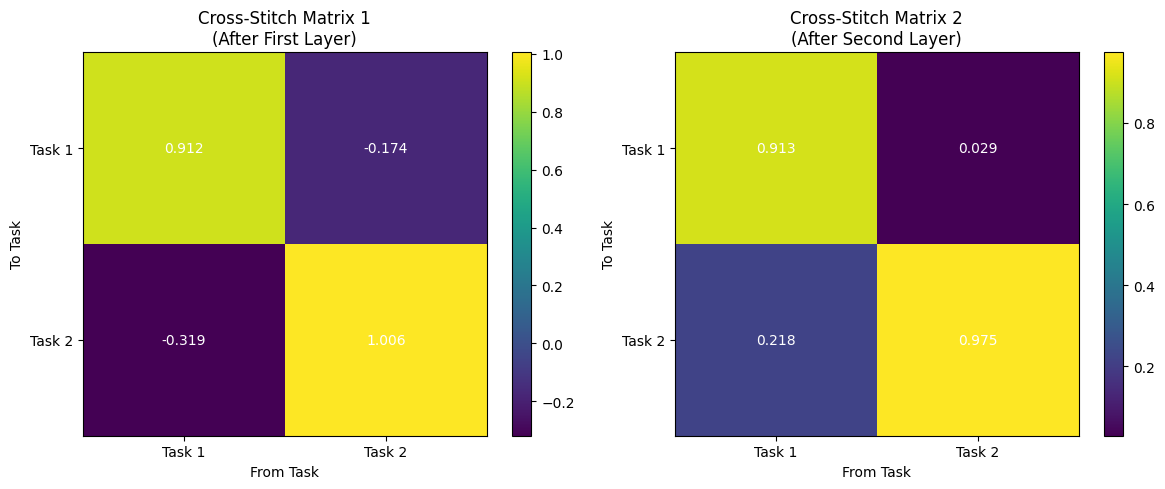


Interpretation:
- Diagonal values: How much each task relies on its own features
- Off-diagonal values: How much tasks share information
- Higher values indicate stronger connections


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap of cross-stitch matrix 1
im1 = axes[0].imshow(alpha1, cmap='viridis', aspect='auto')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Task 1', 'Task 2'])
axes[0].set_yticklabels(['Task 1', 'Task 2'])
axes[0].set_xlabel('From Task')
axes[0].set_ylabel('To Task')
axes[0].set_title('Cross-Stitch Matrix 1\n(After First Layer)')

for i in range(2):
    for j in range(2):
        text = axes[0].text(j, i, f'{alpha1[i, j]:.3f}',
                           ha="center", va="center", color="white")

plt.colorbar(im1, ax=axes[0])

# Heatmap of cross-stitch matrix 2
im2 = axes[1].imshow(alpha2, cmap='viridis', aspect='auto')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Task 1', 'Task 2'])
axes[1].set_yticklabels(['Task 1', 'Task 2'])
axes[1].set_xlabel('From Task')
axes[1].set_ylabel('To Task')
axes[1].set_title('Cross-Stitch Matrix 2\n(After Second Layer)')

for i in range(2):
    for j in range(2):
        text = axes[1].text(j, i, f'{alpha2[i, j]:.3f}',
                           ha="center", va="center", color="white")

plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Diagonal values: How much each task relies on its own features")
print("- Off-diagonal values: How much tasks share information")
print("- Higher values indicate stronger connections")

### Key Insight: Learned Sharing

Cross-stitch networks **automatically learn how to share** between tasks:
- If tasks are similar, off-diagonal weights will be large (more sharing)
- If tasks are different, diagonal weights dominate (less sharing)
- Different layers can have different sharing patterns

This provides more flexibility than hard sharing while being more parameter-efficient than soft sharing.

## 8. When Multi-Task Learning Helps

### Scenario Analysis: When to Use MTL

Multi-task learning works best in these scenarios:

**1. Related Tasks with Shared Structure**
- Example: Object detection + segmentation + depth estimation
- Benefit: Shared visual features (edges, textures, objects)

**2. Limited Data Per Task**
- Example: Medical diagnosis with rare diseases
- Benefit: Tasks regularize each other, prevent overfitting

**3. Auxiliary Tasks for Representation Learning**
- Example: Main task (sentiment) + auxiliary task (part-of-speech tagging)
- Benefit: Auxiliary tasks force learning of useful features

**4. Multi-Objective Optimization**
- Example: Recommendation (relevance + diversity + fairness)
- Benefit: Single model optimizing multiple objectives

**When MTL Might NOT Help:**
- Tasks are completely unrelated (e.g., vision + audio with no semantic connection)
- One task has much more data than others (imbalance)
- Tasks require very different architectures
- Inference time is critical (MTL models can be slower)

### Demonstrate MTL with limited data

In [23]:
def compare_mtl_vs_single_task_limited_data(n_samples=200):
    """Compare MTL vs single-task with limited training data."""
    
    # Create small datasets
    train_small = ToyMultiTaskDataset(n_samples=n_samples, noise=0.2)
    val_small = ToyMultiTaskDataset(n_samples=200, noise=0.2)
    
    train_loader_small = DataLoader(train_small, batch_size=32, shuffle=True)
    val_loader_small = DataLoader(val_small, batch_size=32)
    
    # Train single-task models
    print("Training single-task models...")
    model_single1 = SingleTaskModel().to(device)
    model_single2 = SingleTaskModel().to(device)
    
    optimizer1 = torch.optim.Adam(model_single1.parameters(), lr=0.01)
    optimizer2 = torch.optim.Adam(model_single2.parameters(), lr=0.01)
    
    single_task_losses = {'task1': [], 'task2': []}
    
    for epoch in range(100):
        for x, y1, y2 in train_loader_small:
            x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
            
            # Train task 1 model
            optimizer1.zero_grad()
            pred1 = model_single1(x)
            loss1 = F.mse_loss(pred1, y1)
            loss1.backward()
            optimizer1.step()
            
            # Train task 2 model
            optimizer2.zero_grad()
            pred2 = model_single2(x)
            loss2 = F.mse_loss(pred2, y2)
            loss2.backward()
            optimizer2.step()
        
        # Validation
        if epoch % 10 == 0:
            model_single1.eval()
            model_single2.eval()
            val_loss1, val_loss2 = 0.0, 0.0
            
            with torch.no_grad():
                for x, y1, y2 in val_loader_small:
                    x, y1, y2 = x.to(device), y1.to(device), y2.to(device)
                    val_loss1 += F.mse_loss(model_single1(x), y1).item()
                    val_loss2 += F.mse_loss(model_single2(x), y2).item()
            
            single_task_losses['task1'].append(val_loss1 / len(val_loader_small))
            single_task_losses['task2'].append(val_loss2 / len(val_loader_small))
            
            model_single1.train()
            model_single2.train()
    
    # Train multi-task model
    print("Training multi-task model...")
    model_mtl_small = MultiTaskModel().to(device)
    mtl_losses = train_mtl_weighted(model_mtl_small, train_loader_small, val_loader_small,
                                   weights=(1.0, 0.1), epochs=100, lr=0.01)
    
    return single_task_losses, mtl_losses

# Run comparison
single_losses, mtl_losses_small = compare_mtl_vs_single_task_limited_data(n_samples=200)

print("\nComparison complete!")

Training single-task models...


Training multi-task model...



Comparison complete!


### Visualize MTL benefit with limited data

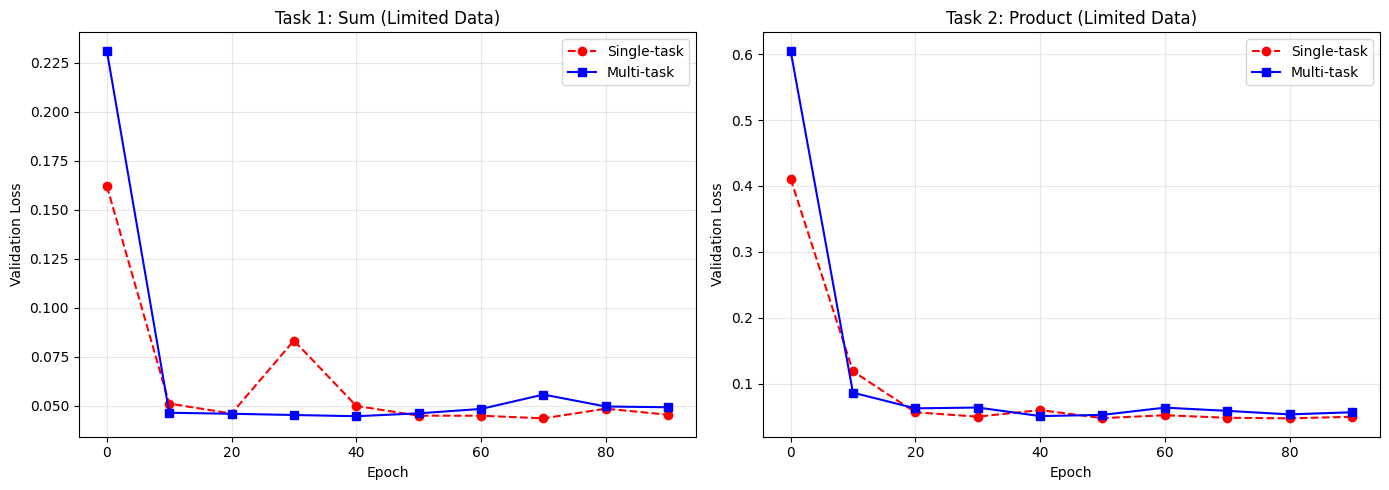


Final Losses (Single-task):
  Task 1: 0.0455
  Task 2: 0.0502

Final Losses (Multi-task):
  Task 1: 0.0506
  Task 2: 0.0620

Improvement from MTL:
  Task 1: -11.1% better
  Task 2: -23.5% better


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Task 1 comparison
axes[0].plot(np.arange(0, 100, 10), single_losses['task1'], 
            label='Single-task', color='red', linestyle='--', marker='o')
axes[0].plot(np.arange(0, 100, 10), mtl_losses_small['val_loss1'][::10], 
            label='Multi-task', color='blue', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Task 1: Sum (Limited Data)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Task 2 comparison
axes[1].plot(np.arange(0, 100, 10), single_losses['task2'], 
            label='Single-task', color='red', linestyle='--', marker='o')
axes[1].plot(np.arange(0, 100, 10), mtl_losses_small['val_loss2'][::10], 
            label='Multi-task', color='blue', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Task 2: Product (Limited Data)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal Losses (Single-task):")
print(f"  Task 1: {single_losses['task1'][-1]:.4f}")
print(f"  Task 2: {single_losses['task2'][-1]:.4f}")

print("\nFinal Losses (Multi-task):")
print(f"  Task 1: {mtl_losses_small['val_loss1'][-1]:.4f}")
print(f"  Task 2: {mtl_losses_small['val_loss2'][-1]:.4f}")

print("\nImprovement from MTL:")
improvement1 = (single_losses['task1'][-1] - mtl_losses_small['val_loss1'][-1]) / single_losses['task1'][-1] * 100
improvement2 = (single_losses['task2'][-1] - mtl_losses_small['val_loss2'][-1]) / single_losses['task2'][-1] * 100
print(f"  Task 1: {improvement1:.1f}% better")
print(f"  Task 2: {improvement2:.1f}% better")

### Key Insight: MTL as Regularization

With limited data, multi-task learning acts as **implicit regularization**:
- Prevents overfitting by forcing the model to learn features useful for multiple tasks
- Tasks act as **inductive biases** for each other
- Similar to data augmentation, but using related tasks instead of transformed data

This is why MTL often outperforms single-task learning in low-data regimes.

## 9. Practical Considerations

### Task Sampling Strategies

When training multi-task models, how do we sample batches?

**Strategy 1: Uniform sampling**
- Sample equally from all tasks
- Simple, but ignores task difficulties and dataset sizes

**Strategy 2: Proportional sampling**
- Sample proportional to dataset sizes
- Common in practice

**Strategy 3: Temperature-based sampling**
- Sample with probabilities: $p_i \propto n_i^{1/T}$
- $T=1$: proportional, $T→0$: uniform, $T→∞$: only largest task

**Strategy 4: Dynamic sampling**
- Adjust sampling based on task performance
- Sample more from tasks with higher loss
- Requires careful tuning

### Implement different task sampling strategies

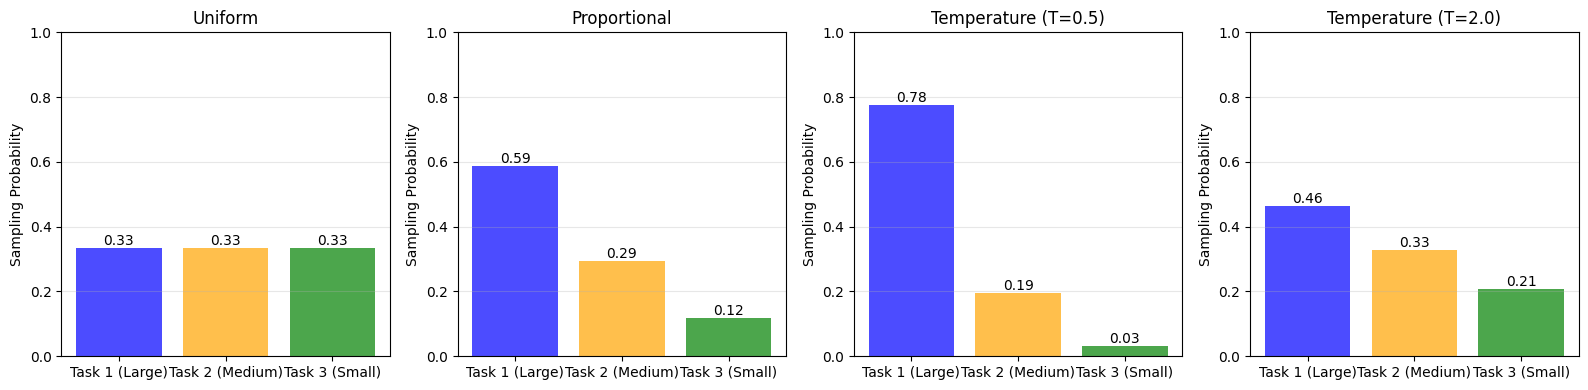


Sampling Strategy Effects:
- Uniform: All tasks sampled equally (ignores dataset sizes)
- Proportional: Larger datasets sampled more (may neglect small tasks)
- Temperature < 1: More balanced (helps small tasks)
- Temperature > 1: More skewed (focuses on large tasks)


In [25]:
class TaskSampler:
    """Sampler for multi-task training with different strategies."""
    
    def __init__(self, task_sizes, strategy='uniform', temperature=1.0):
        """
        Args:
            task_sizes: List of dataset sizes for each task
            strategy: 'uniform', 'proportional', or 'temperature'
            temperature: Temperature for temperature-based sampling
        """
        self.task_sizes = np.array(task_sizes)
        self.strategy = strategy
        self.temperature = temperature
        self.num_tasks = len(task_sizes)
        
        # Compute sampling probabilities
        if strategy == 'uniform':
            self.probs = np.ones(self.num_tasks) / self.num_tasks
        elif strategy == 'proportional':
            self.probs = self.task_sizes / self.task_sizes.sum()
        elif strategy == 'temperature':
            weights = self.task_sizes ** (1.0 / temperature)
            self.probs = weights / weights.sum()
        else:
            raise ValueError(f"Unknown strategy: {strategy}")
    
    def sample_task(self):
        """Sample a task index according to the strategy."""
        return np.random.choice(self.num_tasks, p=self.probs)
    
    def get_probabilities(self):
        """Get sampling probabilities."""
        return self.probs

# Example: 3 tasks with different dataset sizes
task_sizes = [1000, 500, 200]
task_names = ['Task 1 (Large)', 'Task 2 (Medium)', 'Task 3 (Small)']

strategies = [
    ('uniform', 1.0),
    ('proportional', 1.0),
    ('temperature', 0.5),
    ('temperature', 2.0)
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (strategy, temp) in zip(axes, strategies):
    sampler = TaskSampler(task_sizes, strategy=strategy, temperature=temp)
    probs = sampler.get_probabilities()
    
    bars = ax.bar(task_names, probs, color=['blue', 'orange', 'green'], alpha=0.7)
    ax.set_ylabel('Sampling Probability')
    ax.set_ylim(0, 1)
    
    title = f"{strategy.capitalize()}"
    if strategy == 'temperature':
        title += f" (T={temp})"
    ax.set_title(title)
    
    # Add value labels
    for bar, prob in zip(bars, probs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{prob:.2f}', ha='center', va='bottom')
    
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nSampling Strategy Effects:")
print("- Uniform: All tasks sampled equally (ignores dataset sizes)")
print("- Proportional: Larger datasets sampled more (may neglect small tasks)")
print("- Temperature < 1: More balanced (helps small tasks)")
print("- Temperature > 1: More skewed (focuses on large tasks)")

## 10. Key Takeaways

### Summary of Multi-Task Learning

**Core Concepts:**
1. **Shared representations** - Multiple tasks learn from common features
2. **Parameter efficiency** - One model instead of many
3. **Regularization effect** - Tasks prevent overfitting on each other
4. **Transfer learning** - Knowledge flows between related tasks

**Architecture Patterns:**
- **Hard sharing**: Shared encoder + task-specific heads (most common)
- **Soft sharing**: Separate networks with parameter regularization
- **Cross-stitch**: Flexible information sharing at multiple layers

**Critical Challenge: Loss Balancing**
- Naive summation fails due to different loss scales
- Manual weighting requires tuning
- Uncertainty weighting learns task weights automatically
- GradNorm balances gradient magnitudes (not covered but important)

**When to Use MTL:**
- ✓ Related tasks with shared structure
- ✓ Limited data per task
- ✓ Need for parameter efficiency
- ✓ Auxiliary tasks available
- ✗ Tasks are completely unrelated
- ✗ Severe data imbalance

**Practical Tips:**
1. Start with hard parameter sharing
2. Use uncertainty weighting for loss balancing
3. Monitor per-task performance (detect negative transfer)
4. Consider task sampling strategies
5. Compare to single-task baselines

**Extensions Not Covered:**
- Mixture of Experts (task-specific routing)
- GradNorm (gradient-based balancing)
- Task clustering and grouping
- Continual multi-task learning
- Meta-learning for MTL

### Final Visualization: MTL Architecture Comparison

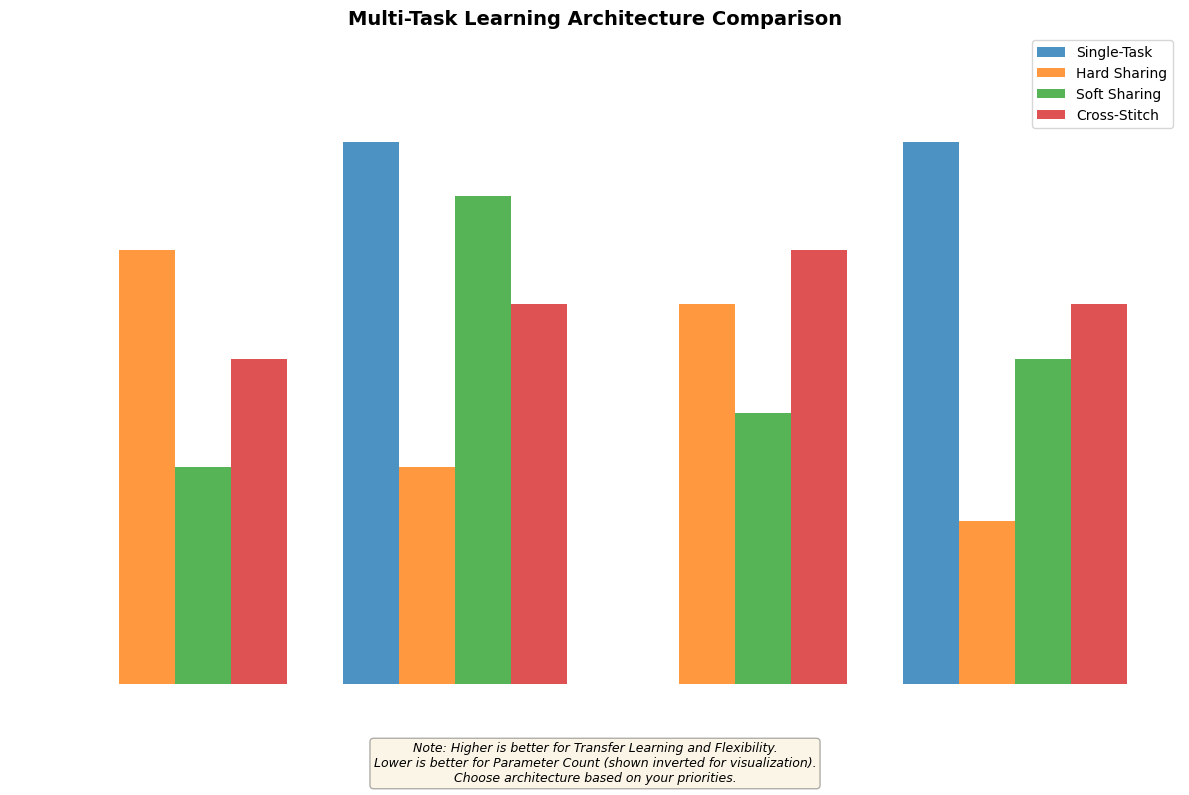

In [26]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

# Define architecture types and their characteristics
architectures = [
    {'name': 'Single-Task', 'sharing': 0, 'params': 100, 'transfer': 0, 'flexibility': 100},
    {'name': 'Hard Sharing', 'sharing': 80, 'params': 40, 'transfer': 70, 'flexibility': 30},
    {'name': 'Soft Sharing', 'sharing': 40, 'params': 90, 'transfer': 50, 'flexibility': 60},
    {'name': 'Cross-Stitch', 'sharing': 60, 'params': 70, 'transfer': 80, 'flexibility': 70},
]

metrics = ['sharing', 'params', 'transfer', 'flexibility']
metric_labels = ['Parameter\nSharing', 'Parameter\nCount', 'Transfer\nLearning', 'Flexibility']

# Create comparison
x = np.arange(len(metrics))
width = 0.2

for i, arch in enumerate(architectures):
    values = [arch[m] for m in metrics]
    offset = (i - 1.5) * width
    ax.bar(x + offset, values, width, label=arch['name'], alpha=0.8)

ax.set_ylabel('Score (Higher = Better/More)', fontsize=12)
ax.set_title('Multi-Task Learning Architecture Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0, 120)
ax.grid(True, alpha=0.3, axis='y')

# Add note
note = (
    "Note: Higher is better for Transfer Learning and Flexibility.\n"
    "Lower is better for Parameter Count (shown inverted for visualization).\n"
    "Choose architecture based on your priorities."
)
ax.text(0.5, -0.15, note, transform=ax.transAxes, 
       fontsize=9, ha='center', style='italic',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

### Conclusion

Multi-task learning is a powerful paradigm that enables:
- **Better generalization** through shared representations
- **Parameter efficiency** by sharing computation across tasks
- **Improved performance** especially with limited data per task

The key challenges are:
1. **Choosing related tasks** that can benefit from shared features
2. **Balancing task losses** to avoid one task dominating training
3. **Selecting the right architecture** for your task relationships

Start with **hard parameter sharing** and **uncertainty-based weighting** for most applications. These provide a good balance of simplicity, efficiency, and performance.

Multi-task learning is widely used in production systems for:
- Computer vision (detection + segmentation + tracking)
- Natural language processing (multiple NLU tasks)
- Recommendation systems (multiple objectives)
- Autonomous driving (perception + prediction + planning)

The field continues to evolve with new architectures (mixture of experts), training methods (gradient-based balancing), and applications (continual learning, meta-learning).